# Phishing URL Detection — Machine Learning Edition

**Project Type:** Machine Learning (classical ML, no deep learning)

**Models compared:**
- Logistic Regression (baseline)
- Decision Tree
- Random Forest
- XGBoost
- LightGBM

**Features:** 50 features — ALL extracted directly from the URL string (zero network calls during training).  
Live inference mode additionally calls WHOIS, DNS, and SSL APIs for the remaining network-based features.

---
### Feature categories
| # | Category | Count |
|---|---|---|
| 1 | URL-level lexical | 13 |
| 2 | Domain-level | 14 |
| 3 | Brand & keyword signals | 7 |
| 4 | Path & query structure | 9 |
| 5 | Advanced lexical | 7 |
| **Total** | | **50** |

In [1]:
# ── Cell 1: Install any missing libraries ──────────────────────────────────
# Uncomment if needed:
# !pip install xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn python-whois
print('Libraries ready.')

Libraries ready.


In [2]:
# ── Cell 2: Imports ────────────────────────────────────────────────────────
import re
import math
import time
import socket
import ssl
import pickle
import warnings
from pathlib import Path
from urllib.parse import urlparse, parse_qs, unquote
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection    import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.pipeline           import Pipeline
from sklearn.metrics            import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection         import permutation_importance

import xgboost  as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

print('All imports OK')

All imports OK


In [3]:
# ── Cell 3: Feature engineering constants ──────────────────────────────────

# Suspicious TLDs (frequently abused in phishing)
SUSPICIOUS_TLDS = {
    'tk', 'ml', 'ga', 'cf', 'gq',
    'xyz', 'pw', 'top', 'club', 'online',
    'site', 'info', 'biz', 'cc', 'ws',
    'cn', 'ru', 'co', 'in', 'io'
}

# URL shortening services
SHORTENERS = {
    'bit.ly', 'tinyurl.com', 'goo.gl', 't.co', 'ow.ly',
    'short.link', 'buff.ly', 'adf.ly', 'is.gd', 'cli.gs',
    'ift.tt', 'dlvr.it', 'mcaf.ee', 'su.pr', 'twit.ac',
    'snipurl.com', 'short.to', 'shorturl.at'
}

# Keywords in URL path/query that indicate phishing pages
PHISHING_KEYWORDS = [
    'login', 'logon', 'signin', 'sign-in', 'sign_in',
    'verify', 'verification', 'validate', 'validation',
    'secure', 'security', 'account', 'update', 'upgrade',
    'confirm', 'password', 'passwd', 'credential',
    'webscr', 'cmd=', 'banking', 'support',
    'auth', 'authenticate', 'authorization',
    'recover', 'recovery', 'reset', 'unlock',
    'suspend', 'suspended', 'limited', 'unusual',
    'click', 'redirect', 'response', 'token'
]

# Well-known brands whose names are spoofed in phishing domains
BRAND_NAMES = [
    'google', 'paypal', 'amazon', 'apple', 'microsoft',
    'facebook', 'instagram', 'netflix', 'twitter', 'linkedin',
    'dropbox', 'yahoo', 'outlook', 'office365', 'office',
    'chase', 'wellsfargo', 'citibank', 'bankofamerica',
    'ebay', 'alibaba', 'aliexpress', 'walmart', 'target',
    'fedex', 'dhl', 'ups', 'usps', 'royal', 'post',
    'icloud', 'onedrive', 'sharepoint', 'docusign',
    'steam', 'discord', 'whatsapp', 'telegram'
]

# Suspicious file extensions in URL path
SUSPICIOUS_EXTENSIONS = {
    '.exe', '.bat', '.cmd', '.scr', '.pif', '.vbs',
    '.js', '.jar', '.msi', '.dll', '.com',
    '.php', '.asp', '.aspx', '.cgi', '.pl'
}

# Non-standard ports commonly used by phishing
STANDARD_PORTS = {80, 443, 8080, 8443}

print('Constants loaded.')

Constants loaded.


In [4]:
# ── Cell 4: Helper functions ───────────────────────────────────────────────

def shannon_entropy(s: str) -> float:
    """Shannon entropy of a string (bits per character)."""
    if not s:
        return 0.0
    freq = Counter(s)
    n = len(s)
    return -sum((c / n) * math.log2(c / n) for c in freq.values())


def longest_run(s: str, char_type: str = 'digit') -> int:
    """Longest consecutive run of digits or alpha chars."""
    if not s:
        return 0
    test = str.isdigit if char_type == 'digit' else str.isalpha
    max_run, cur = 0, 0
    for c in s:
        if test(c):
            cur += 1
            max_run = max(max_run, cur)
        else:
            cur = 0
    return max_run


def max_consecutive_repeat(s: str) -> int:
    """Longest run of a single repeated character."""
    if not s:
        return 0
    max_run, cur, prev = 1, 1, s[0]
    for c in s[1:]:
        cur = cur + 1 if c == prev else 1
        max_run = max(max_run, cur)
        prev = c
    return max_run


def is_ip(domain: str) -> int:
    """Return 1 if domain is an IPv4 address."""
    return int(bool(re.fullmatch(r'(\d{1,3}\.){3}\d{1,3}', domain)))


def is_ipv6(url: str) -> int:
    """Return 1 if URL contains an IPv6 address (hex groups in brackets)."""
    return int(bool(re.search(r'\[([0-9a-fA-F]{0,4}:){2,}[0-9a-fA-F]{0,4}\]', url)))


def safe_parse(url: str):
    """Parse URL, prepending http:// if no scheme is present."""
    s = url.strip()
    if not re.match(r'^https?://', s, re.I):
        s = 'http://' + s
    try:
        return urlparse(s)
    except Exception:
        return urlparse('')


print('Helpers loaded.')

Helpers loaded.


In [5]:
# ── Cell 5: Master feature extraction function (50 features) ───────────────

def extract_features(url: str) -> dict:
    """
    Extract all 50 lexical features from a URL string.
    Returns a dict so feature names are always explicit.
    No network calls — works entirely offline.
    """
    url     = str(url).strip()
    url_low = url.lower()

    p       = safe_parse(url)
    scheme  = p.scheme
    netloc  = p.netloc.lower()
    path    = p.path
    query   = p.query
    fragment= p.fragment

    # Strip port from netloc for clean domain parsing
    domain_port = netloc.split(':')
    domain_full = domain_port[0]                 # e.g. sub.example.com
    port_str    = domain_port[1] if len(domain_port) > 1 else ''

    # Remove www. for domain analysis
    domain = domain_full.lstrip('www.')
    parts  = domain.split('.')
    tld    = parts[-1] if parts else ''
    sld    = parts[-2] if len(parts) >= 2 else ''  # second-level domain

    # Subdomain = everything before sld.tld
    subdomain = '.'.join(parts[:-2]) if len(parts) > 2 else ''

    # ─── Category 1: URL-level lexical (13 features) ──────────────────────
    feat = {}

    feat['url_length']          = len(url)
    feat['dot_count']           = url.count('.')
    feat['hyphen_count']        = url.count('-')
    feat['underscore_count']    = url.count('_')
    feat['slash_count']         = url.count('/')
    feat['digit_count']         = sum(c.isdigit() for c in url)
    feat['letter_count']        = sum(c.isalpha() for c in url)
    feat['special_char_count']  = len(re.findall(r'[^a-z0-9.\-/:?=&%#@_~+]', url_low))
    feat['at_symbol']           = int('@' in url)
    feat['double_slash_redirect']= int('//' in url[7:])   # skip scheme
    feat['url_entropy']         = shannon_entropy(url_low)
    feat['digit_ratio']         = feat['digit_count'] / max(len(url), 1)
    feat['percent_encoded_count']= len(re.findall(r'%[0-9a-fA-F]{2}', url))

    # ─── Category 2: Domain-level (14 features) ───────────────────────────
    feat['domain_length']       = len(domain)
    feat['domain_entropy']      = shannon_entropy(domain)
    feat['has_ipv4']            = is_ip(domain_full)
    feat['has_ipv6']            = is_ipv6(url)
    feat['uses_https']          = int(scheme == 'https')
    feat['subdomain_count']     = len([s for s in subdomain.split('.') if s])
    feat['domain_has_hyphen']   = int('-' in sld)
    feat['domain_has_digit']    = int(any(c.isdigit() for c in domain))
    feat['suspicious_tld']      = int(tld in SUSPICIOUS_TLDS)
    feat['is_shortener']        = int(any(sh in domain_full for sh in SHORTENERS))
    feat['tld_length']          = len(tld)
    feat['longest_digit_run']   = longest_run(domain, 'digit')
    feat['max_char_repeat']     = max_consecutive_repeat(domain)
    feat['is_punycode']         = int('xn--' in domain_full)

    # ─── Category 3: Brand & keyword signals (7 features) ─────────────────
    # Brand appears in subdomain but NOT in sld.tld
    #   e.g. paypal.secure-login.com → brand in subdomain
    tld_sld = f'{sld}.{tld}'
    feat['brand_in_subdomain']  = int(
        any(b in subdomain for b in BRAND_NAMES) and
        not any(b in tld_sld for b in BRAND_NAMES)
    )
    feat['brand_in_path']       = int(any(b in path.lower() for b in BRAND_NAMES))
    feat['brand_count_url']     = sum(b in url_low for b in BRAND_NAMES)
    feat['phish_kw_url']        = int(any(k in url_low          for k in PHISHING_KEYWORDS))
    feat['phish_kw_path']       = int(any(k in path.lower()     for k in PHISHING_KEYWORDS))
    feat['phish_kw_domain']     = int(any(k in domain_full      for k in PHISHING_KEYWORDS))
    feat['phish_kw_query']      = int(any(k in query.lower()    for k in PHISHING_KEYWORDS))

    # ─── Category 4: Path & query structure (9 features) ──────────────────
    port_num = int(port_str) if port_str.isdigit() else (443 if scheme == 'https' else 80)
    feat['has_port']            = int(bool(port_str))
    feat['non_standard_port']   = int(port_num not in STANDARD_PORTS)
    feat['path_length']         = len(path)
    feat['query_length']        = len(query)
    feat['query_param_count']   = len(parse_qs(query))
    feat['path_depth']          = len([s for s in path.split('/') if s])
    last_seg = path.split('/')[-1] if '/' in path else path
    feat['last_seg_length']     = len(last_seg)
    feat['suspicious_extension']= int(
        any(last_seg.lower().endswith(ext) for ext in SUSPICIOUS_EXTENSIONS)
    )
    feat['has_fragment']        = int(bool(fragment))

    # ─── Category 5: Advanced lexical (7 features) ────────────────────────
    # Token length statistics over sld characters
    tokens = re.split(r'[^a-z0-9]', sld.lower())
    tokens = [t for t in tokens if t]
    feat['avg_token_length']    = (sum(len(t) for t in tokens) / len(tokens)) if tokens else 0
    feat['longest_token_length']= max((len(t) for t in tokens), default=0)

    feat['tld_in_path']         = int(f'.{tld}' in path.lower() if tld else False)
    feat['double_extension']    = int(
        bool(re.search(r'\.(php|asp|aspx|html?|cgi)\.(php|asp|aspx|html?)$', last_seg.lower()))
    )
    feat['has_www']             = int('www.' in domain_full)

    # Ratio of consonants to vowels in domain (phishing domains are often random)
    vowels     = sum(c in 'aeiou' for c in domain if c.isalpha())
    consonants = sum(c.isalpha() and c not in 'aeiou' for c in domain)
    feat['consonant_vowel_ratio']= consonants / max(vowels, 1)

    # Domain digit ratio
    d_alpha  = sum(c.isalpha()  for c in domain)
    d_digits = sum(c.isdigit()  for c in domain)
    feat['domain_digit_ratio']  = d_digits / max(d_alpha + d_digits, 1)

    return feat


FEATURE_NAMES = list(extract_features('https://example.com').keys())
print(f'Total features: {len(FEATURE_NAMES)}')
print('\nAll feature names:')
for i, f in enumerate(FEATURE_NAMES, 1):
    print(f'  {i:02d}. {f}')

Total features: 50

All feature names:
  01. url_length
  02. dot_count
  03. hyphen_count
  04. underscore_count
  05. slash_count
  06. digit_count
  07. letter_count
  08. special_char_count
  09. at_symbol
  10. double_slash_redirect
  11. url_entropy
  12. digit_ratio
  13. percent_encoded_count
  14. domain_length
  15. domain_entropy
  16. has_ipv4
  17. has_ipv6
  18. uses_https
  19. subdomain_count
  20. domain_has_hyphen
  21. domain_has_digit
  22. suspicious_tld
  23. is_shortener
  24. tld_length
  25. longest_digit_run
  26. max_char_repeat
  27. is_punycode
  28. brand_in_subdomain
  29. brand_in_path
  30. brand_count_url
  31. phish_kw_url
  32. phish_kw_path
  33. phish_kw_domain
  34. phish_kw_query
  35. has_port
  36. non_standard_port
  37. path_length
  38. query_length
  39. query_param_count
  40. path_depth
  41. last_seg_length
  42. suspicious_extension
  43. has_fragment
  44. avg_token_length
  45. longest_token_length
  46. tld_in_path
  47. double_exten

In [7]:
# ── Cell 6: Load & prepare dataset ────────────────────────────────────────
data_path = Path('urldata.csv')
df = pd.read_csv(data_path)
df.columns = df.columns.str.strip()

df = df[['url', 'result']].dropna()
df.columns = ['url', 'label']
df['label'] = df['label'].astype(int)

print(f'Rows     : {len(df):,}')
print(f'Benign   : {(df["label"]==0).sum():,}  ({(df["label"]==0).mean()*100:.1f}%)')
print(f'Phishing : {(df["label"]==1).sum():,}  ({(df["label"]==1).mean()*100:.1f}%)')
df.head()

Rows     : 174,434
Benign   : 149,998  (86.0%)
Phishing : 24,436  (14.0%)


,url,label
0,https://www.google.com,0
1,https://www.youtube.com,0
2,https://www.facebook.com,0
3,https://www.baidu.com,0
4,https://www.wikipedia.org,0


In [8]:
# ── Cell 7: Feature extraction (may take 3-5 min for 450k rows) ─────────────
print('Extracting features...')
t0 = time.time()

features_list = [extract_features(u) for u in df['url']]
X_df = pd.DataFrame(features_list, columns=FEATURE_NAMES)
y    = df['label'].values

print(f'Done in {time.time()-t0:.1f}s')
print(f'Feature matrix shape: {X_df.shape}')
X_df.head()

Extracting features...
Done in 36.2s
Feature matrix shape: (174434, 50)


,url_length,dot_count,hyphen_count,underscore_count,slash_count,digit_count,letter_count,special_char_count,at_symbol,double_slash_redirect,...,last_seg_length,suspicious_extension,has_fragment,avg_token_length,longest_token_length,tld_in_path,double_extension,has_www,consonant_vowel_ratio,domain_digit_ratio
0,22,2,0,0,2,0,17,0,0,0,...,0,0,0,6.0,6,0,0,1,1.250000,0.0
1,23,2,0,0,2,0,18,0,0,0,...,0,0,0,7.0,7,0,0,1,1.000000,0.0
2,24,2,0,0,2,0,19,0,0,0,...,0,0,0,8.0,8,0,0,1,1.200000,0.0
3,21,2,0,0,2,0,16,0,0,0,...,0,0,0,5.0,5,0,0,1,1.000000,0.0
4,25,2,0,0,2,0,20,0,0,0,...,0,0,0,8.0,8,0,0,1,0.833333,0.0


In [9]:
# ── Cell 8: Exploratory data analysis ─────────────────────────────────────
print('=== Feature Statistics (Phishing vs Benign) ===')
X_df['label'] = y
stats = X_df.groupby('label')[FEATURE_NAMES].mean().T
stats.columns = ['Benign (mean)', 'Phishing (mean)']
stats['Difference'] = (stats['Phishing (mean)'] - stats['Benign (mean)']).abs()
stats = stats.sort_values('Difference', ascending=False)
print(stats.head(20).to_string())
X_df.drop(columns=['label'], inplace=True)

=== Feature Statistics (Phishing vs Benign) ===
                      Benign (mean)  Phishing (mean)  Difference
url_length                58.950013        73.706540   14.756527
query_length               2.485620        15.869946   13.384326
letter_count              45.260650        53.971190    8.710540
last_seg_length           13.132908         7.479170    5.653738
digit_count                3.034860         8.198887    5.164026
path_length               26.642349        29.987150    3.344802
slash_count                4.266857         5.259330    0.992474
domain_length             17.677696        18.618759    0.941064
uses_https                 1.000000         0.227288    0.772712
path_depth                 1.948419         2.713415    0.764995
has_www                    1.000000         0.320920    0.679080
hyphen_count               1.382618         0.711819    0.670800
longest_token_length       8.915246         9.361229    0.445984
avg_token_length           8.870724       

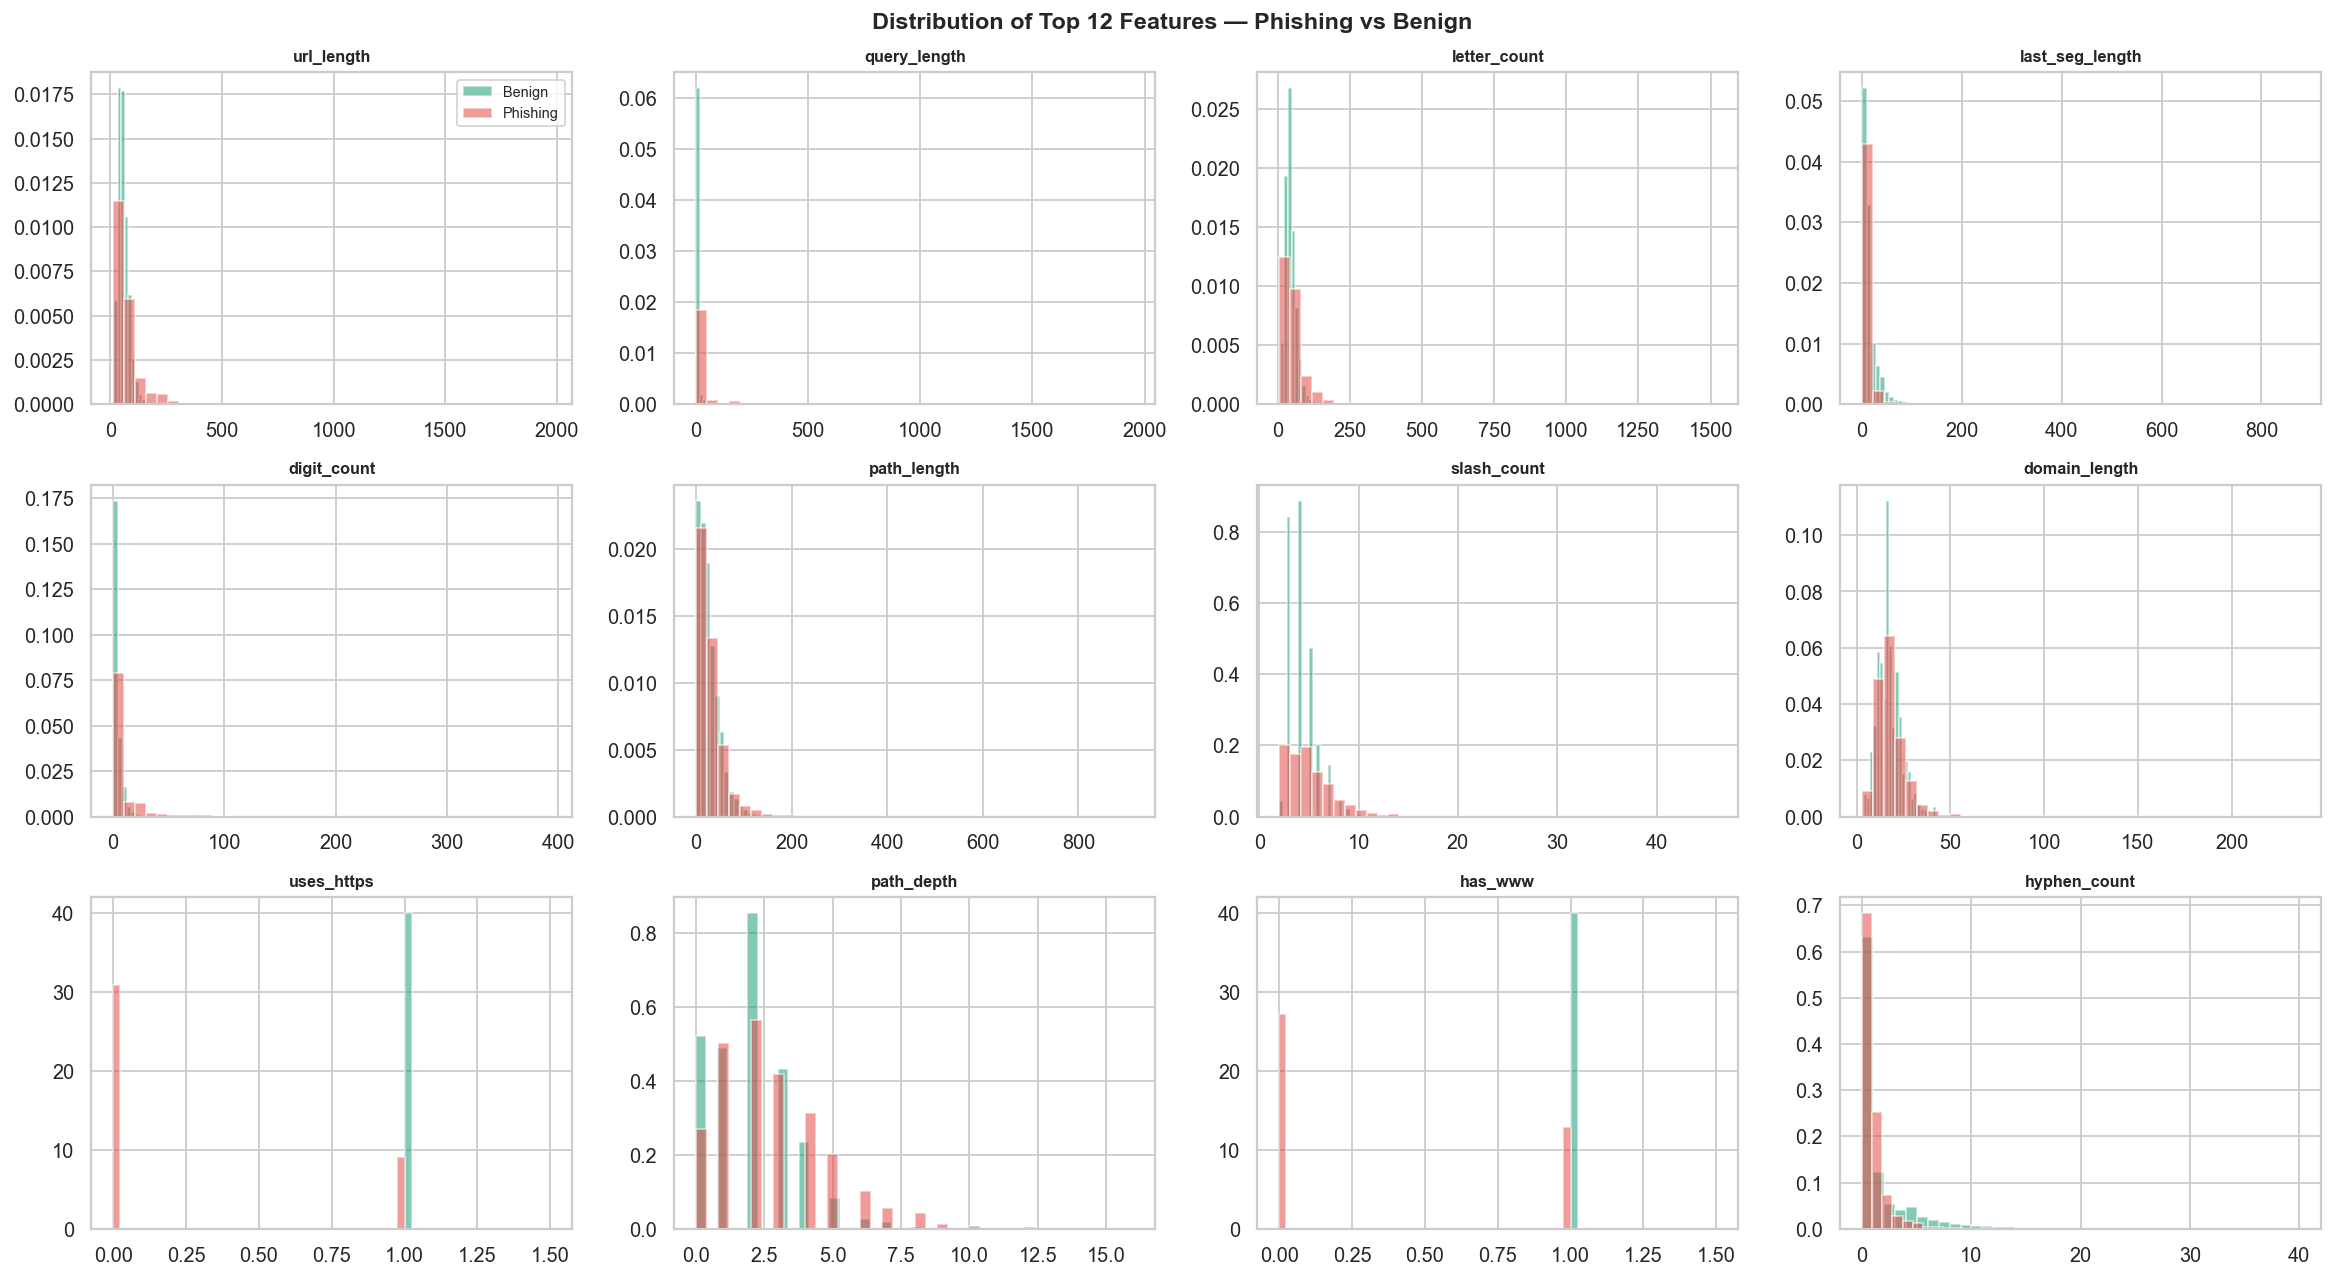

In [10]:
# ── Cell 9: Visualise top distinguishing features ─────────────────────────
top_feats = stats.head(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.ravel()

for i, feat in enumerate(top_feats):
    ax = axes[i]
    for label, color, name in [(0, '#1D9E75', 'Benign'), (1, '#E24B4A', 'Phishing')]:
        vals = X_df.loc[y == label, feat]
        ax.hist(vals, bins=40, alpha=0.55, color=color, label=name, density=True)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Distribution of Top 12 Features — Phishing vs Benign', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

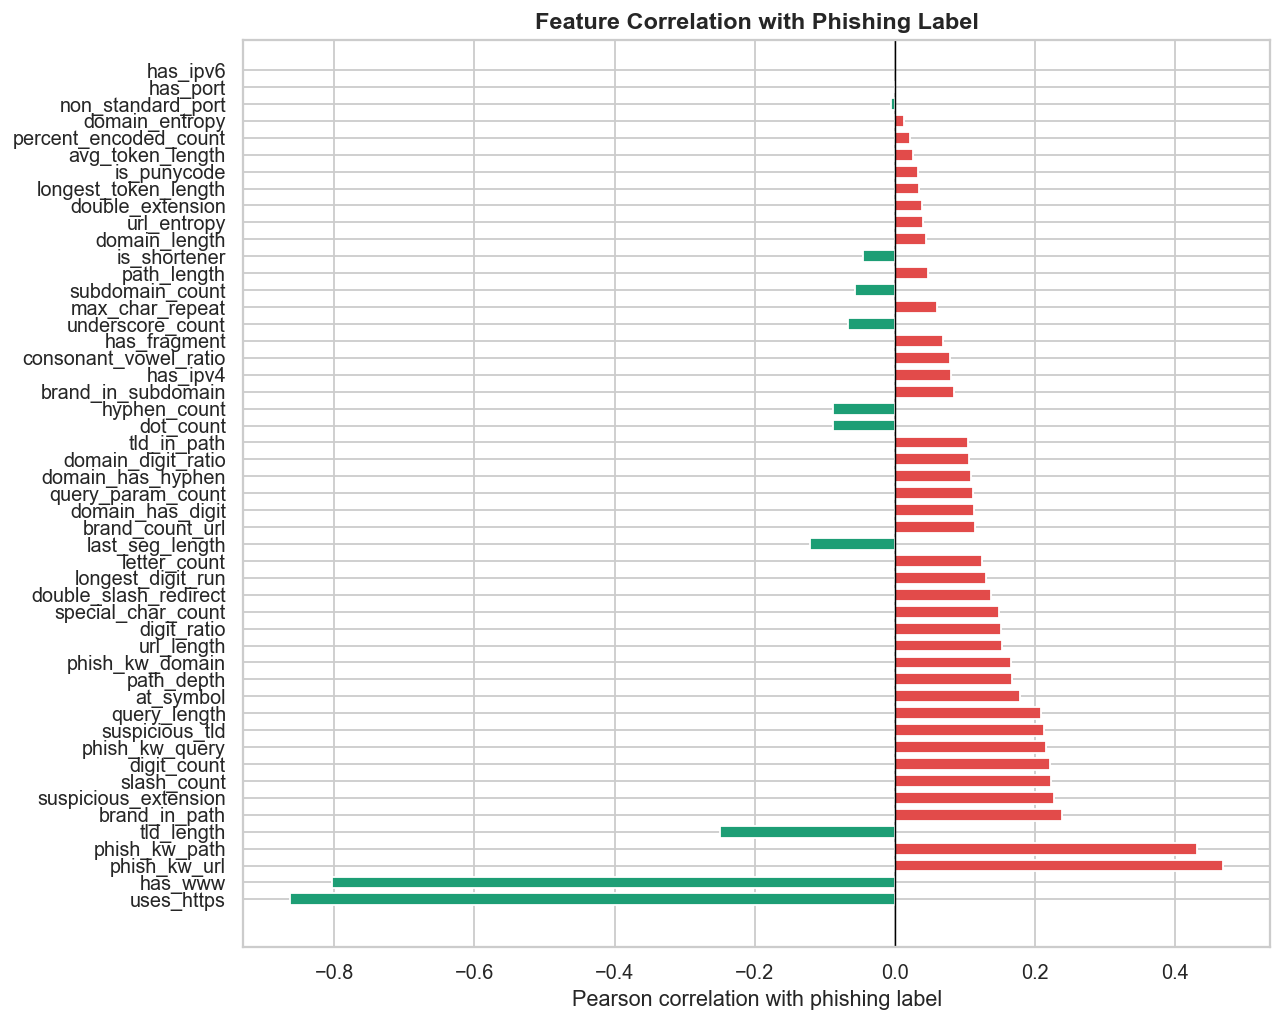

In [11]:
# ── Cell 10: Feature correlation heatmap ──────────────────────────────────
corr_with_label = X_df.copy()
corr_with_label['label'] = y
corr = corr_with_label.corr()['label'].drop('label').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E24B4A' if v > 0 else '#1D9E75' for v in corr]
ax.barh(corr.index, corr.values, color=colors, height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with phishing label')
ax.set_title('Feature Correlation with Phishing Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=130, bbox_inches='tight')
plt.show()

In [12]:
# ── Cell 11: Train / test split ────────────────────────────────────────────
X = X_df.values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserve class ratio in both splits
)

# Scaler (used only by Logistic Regression — tree models don't need it)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Class weights for imbalanced dataset
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: cw[0], 1: cw[1]}

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Class weights: benign={cw[0]:.3f}, phishing={cw[1]:.3f}')

Train : (139547, 50)  |  Test : (34887, 50)
Class weights: benign=0.581, phishing=3.569


In [13]:
# ── Cell 12: Define all ML models ─────────────────────────────────────────
MODELS = {

    'Logistic Regression': LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver='lbfgs',
        class_weight='balanced',
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=15,
        min_samples_split=20,
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=10,
        max_features='sqrt',
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=300,
        max_depth=7,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=cw[1] / cw[0],   # handles class imbalance
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1,
        random_state=42
    ),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=7,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42,
        verbose=-1
    ),

}

print('Models defined:')
for name in MODELS:
    print(f'  - {name}')

Models defined:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - XGBoost
  - LightGBM


In [14]:
# ── Cell 13: Train all models and collect metrics ──────────────────────────
results = {}

for name, model in MODELS.items():
    print(f'\nTraining: {name} ...', end=' ')
    t0 = time.time()

    # Logistic Regression uses scaled features; trees use raw
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test

    model.fit(Xtr, y_train)
    elapsed = time.time() - t0

    y_pred      = model.predict(Xte)
    y_prob      = model.predict_proba(Xte)[:, 1]

    results[name] = {
        'model'     : model,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred),
        'recall'    : recall_score(y_test, y_pred),
        'f1'        : f1_score(y_test, y_pred),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        'train_sec' : elapsed,
    }

    print(f'Done in {elapsed:.1f}s  |  F1={results[name]["f1"]:.4f}  AUC={results[name]["roc_auc"]:.4f}')

print('\nAll models trained.')


Training: Logistic Regression ... Done in 1.1s  |  F1=0.9861  AUC=0.9974

Training: Decision Tree ... Done in 3.7s  |  F1=0.9806  AUC=0.9954

Training: Random Forest ... Done in 117.5s  |  F1=0.9920  AUC=0.9994

Training: XGBoost ... Done in 13.8s  |  F1=0.9916  AUC=0.9992

Training: LightGBM ... Done in 8.4s  |  F1=0.9921  AUC=0.9991

All models trained.


In [15]:
# ── Cell 14: Model comparison table ───────────────────────────────────────
comparison = pd.DataFrame({
    name: {
        'Accuracy'  : f"{r['accuracy']*100:.2f}%",
        'Precision' : f"{r['precision']*100:.2f}%",
        'Recall'    : f"{r['recall']*100:.2f}%",
        'F1 Score'  : f"{r['f1']*100:.2f}%",
        'ROC-AUC'   : f"{r['roc_auc']:.4f}",
        'Train (s)' : f"{r['train_sec']:.1f}s",
    }
    for name, r in results.items()
}).T

print('='*80)
print('MODEL COMPARISON')
print('='*80)
print(comparison.to_string())

# Find the best model by F1
best_name = max(results, key=lambda k: results[k]['f1'])
print(f'\nBest model by F1: {best_name} (F1 = {results[best_name]["f1"]*100:.2f}%)')

MODEL COMPARISON
                    Accuracy Precision  Recall F1 Score ROC-AUC Train (s)
Logistic Regression   99.61%    98.77%  98.44%   98.61%  0.9974      1.1s
Decision Tree         99.45%    97.57%  98.55%   98.06%  0.9954      3.7s
Random Forest         99.78%    99.90%  98.51%   99.20%  0.9994    117.5s
XGBoost               99.76%    99.71%  98.61%   99.16%  0.9992     13.8s
LightGBM              99.78%    99.73%  98.69%   99.21%  0.9991      8.4s

Best model by F1: LightGBM (F1 = 99.21%)


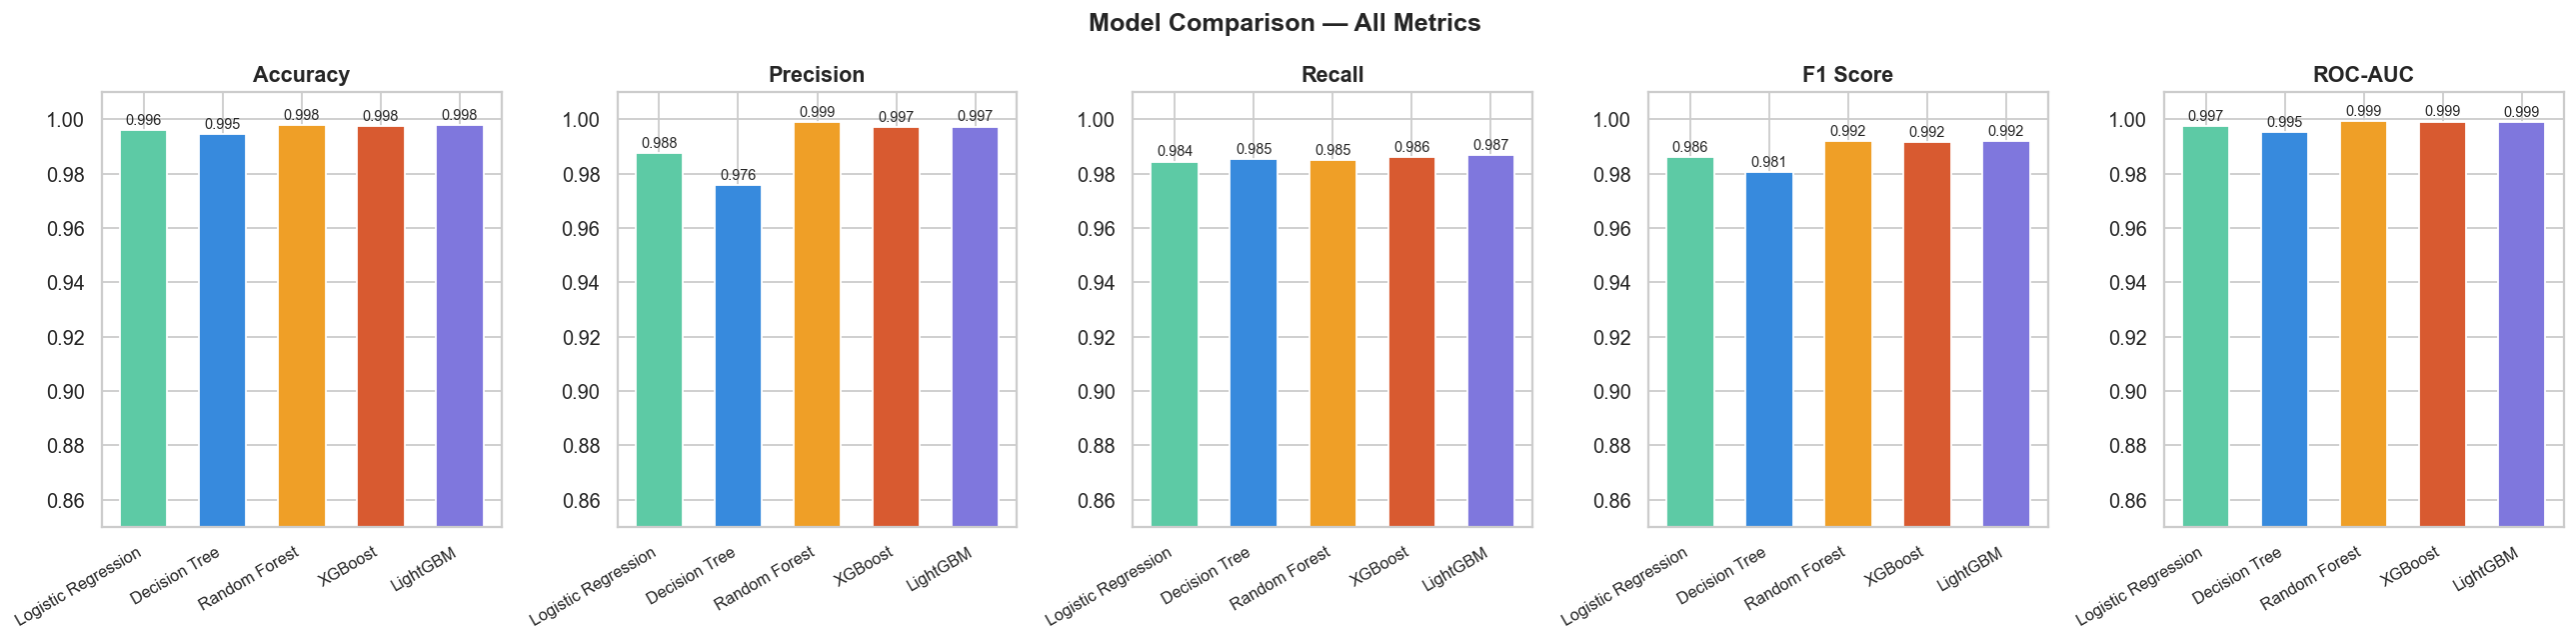

In [16]:
# ── Cell 15: Visual model comparison ──────────────────────────────────────
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
model_names   = list(results.keys())
colors        = ['#5DCAA5', '#378ADD', '#EF9F27', '#D85A30', '#7F77DD']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, metric, label in zip(axes, metrics, metric_labels):
    values = [results[m][metric] for m in model_names]
    bars   = ax.bar(range(len(model_names)), values, color=colors[:len(model_names)], width=0.6)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(0.85, 1.01)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

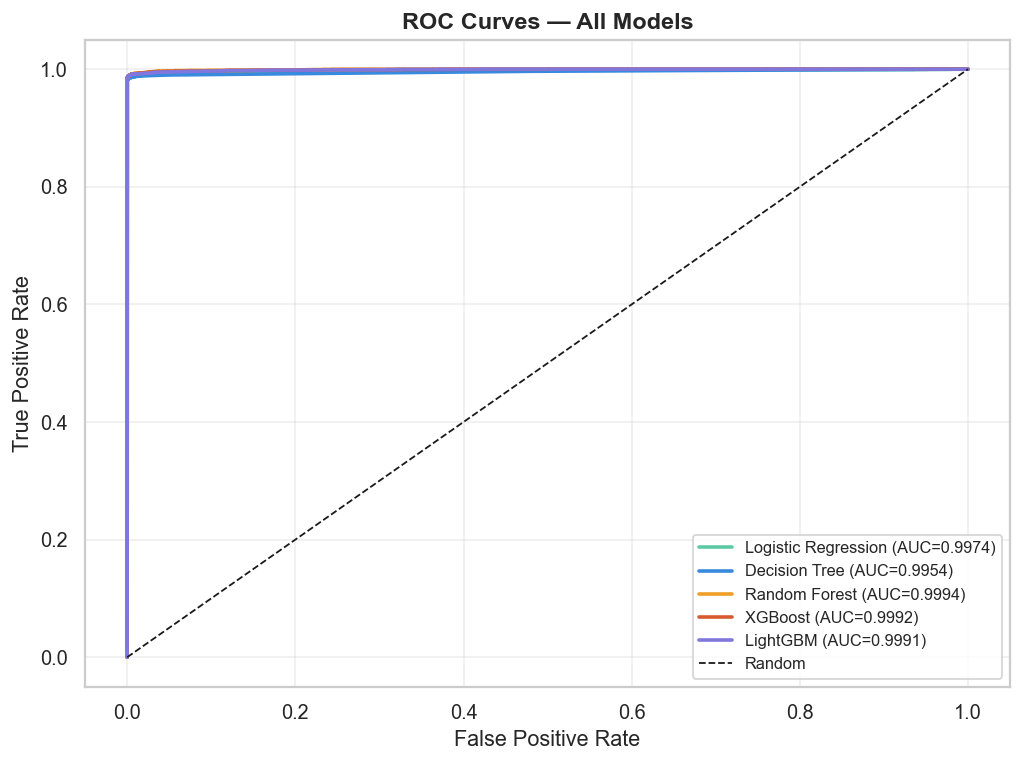

In [17]:
# ── Cell 16: ROC curves for all models ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC={r['roc_auc']:.4f})")

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=130, bbox_inches='tight')
plt.show()

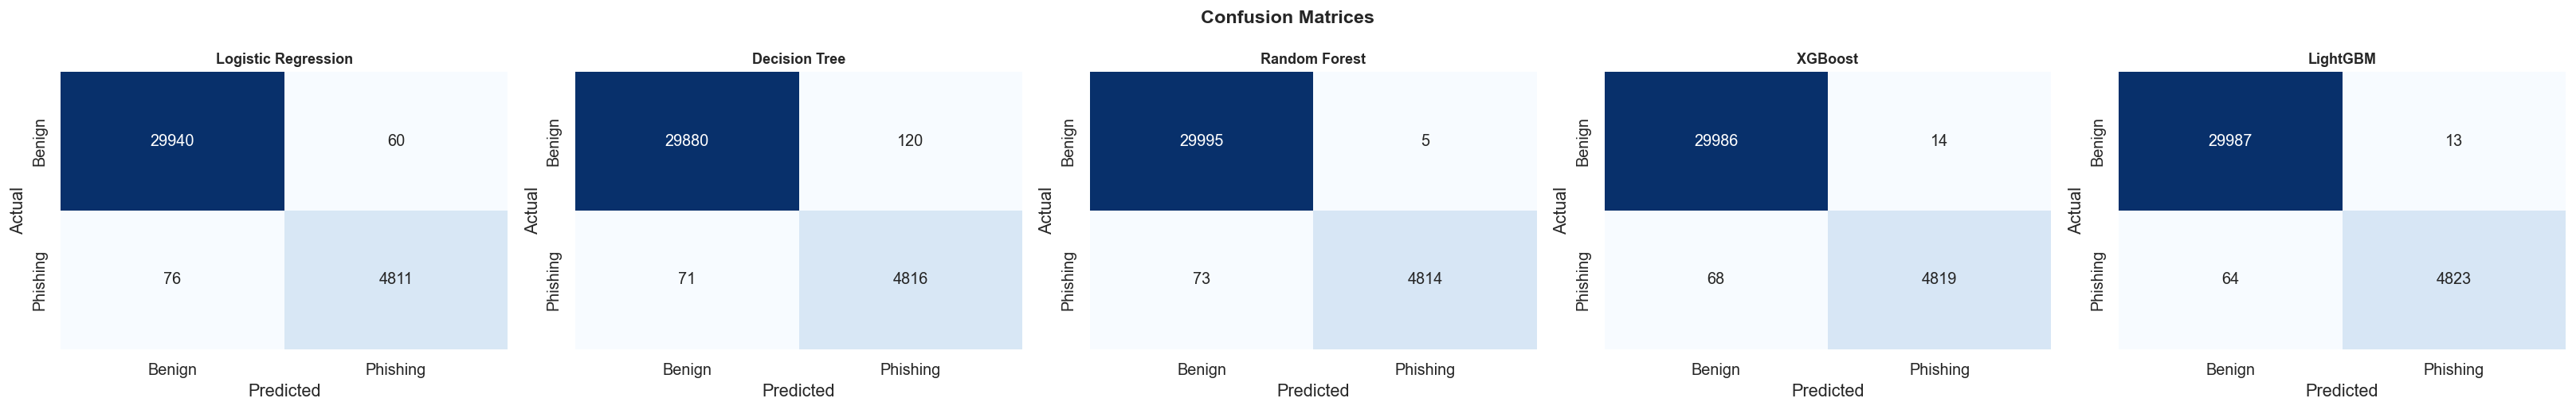

In [18]:
# ── Cell 17: Confusion matrices for all models ────────────────────────────
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Benign', 'Phishing'],
        yticklabels=['Benign', 'Phishing'],
        ax=ax, cbar=False
    )
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()

In [19]:
# ── Cell 18: Detailed classification report for best model ────────────────
best = results[best_name]
print(f'=== Detailed Report: {best_name} ===')
print(classification_report(y_test, best['y_pred'],
                             target_names=['Benign', 'Phishing']))
tn, fp, fn, tp = confusion_matrix(y_test, best['y_pred']).ravel()
print(f'True Negatives  (Benign   -> Benign)   : {tn:,}')
print(f'False Positives (Benign   -> Phishing) : {fp:,}  <- false alarms')
print(f'False Negatives (Phishing -> Benign)   : {fn:,}  <- missed attacks  ***')
print(f'True Positives  (Phishing -> Phishing) : {tp:,}')

=== Detailed Report: LightGBM ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     30000
    Phishing       1.00      0.99      0.99      4887

    accuracy                           1.00     34887
   macro avg       1.00      0.99      1.00     34887
weighted avg       1.00      1.00      1.00     34887

True Negatives  (Benign   -> Benign)   : 29,987
False Positives (Benign   -> Phishing) : 13  <- false alarms
False Negatives (Phishing -> Benign)   : 64  <- missed attacks  ***
True Positives  (Phishing -> Phishing) : 4,823


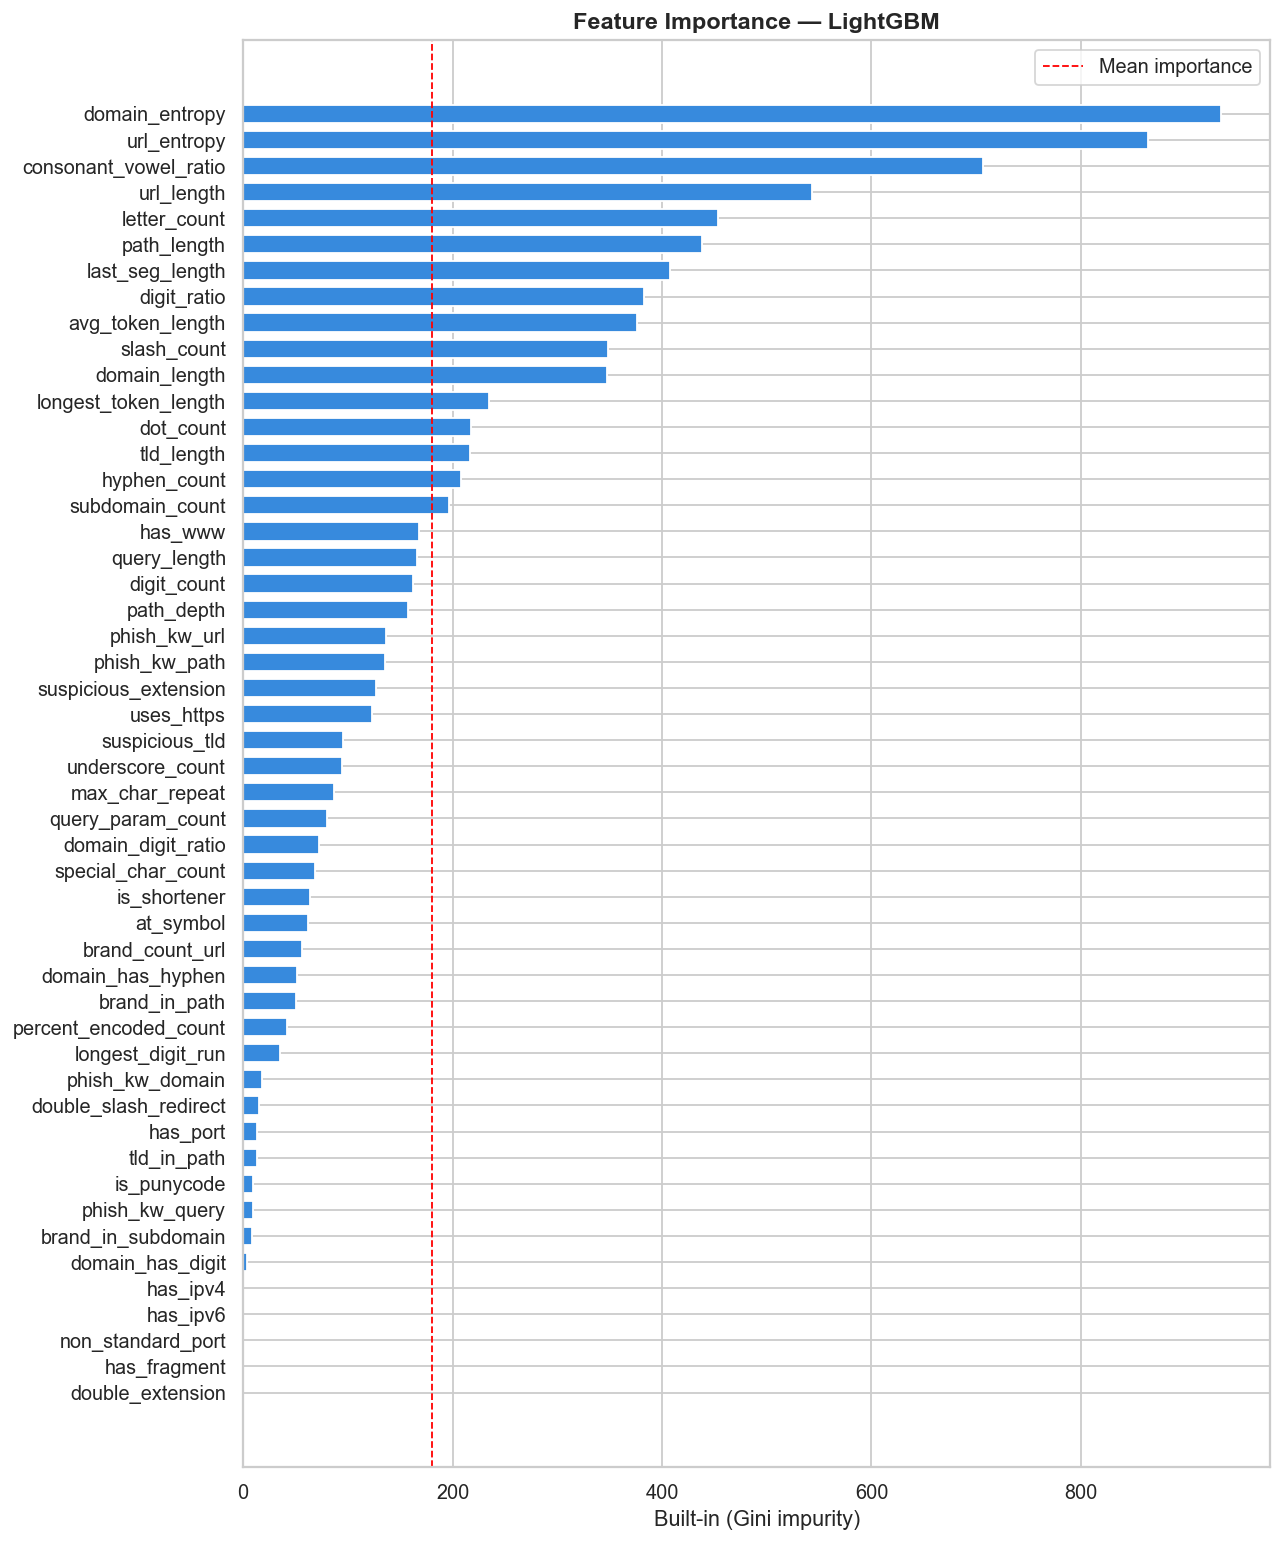

In [20]:
# ── Cell 19: Feature importance from best model ────────────────────────────
best_model = best['model']

# Tree-based models have built-in feature_importances_
if hasattr(best_model, 'feature_importances_'):
    fi = best_model.feature_importances_
    fi_type = 'Built-in (Gini impurity)'
else:
    # For Logistic Regression: use absolute coefficient values
    fi = np.abs(best_model.coef_[0])
    fi_type = 'Coefficient magnitude'

fi_df = pd.DataFrame({'feature': FEATURE_NAMES, 'importance': fi})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
bars = ax.barh(fi_df['feature'], fi_df['importance'],
               color='#378ADD', height=0.7)
ax.set_xlabel(fi_type)
ax.set_title(f'Feature Importance — {best_name}',
             fontsize=13, fontweight='bold')
ax.axvline(fi_df['importance'].mean(), color='red', linestyle='--',
           linewidth=1, label='Mean importance')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

In [21]:
# ── Cell 20: 5-fold cross-validation for best model ───────────────────────
print(f'Running 5-fold cross-validation for {best_name}...')

Xcv = X_train_sc if best_name == 'Logistic Regression' else X_train
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1  = cross_val_score(best_model, Xcv, y_train, cv=cv,
                          scoring='f1',      n_jobs=-1)
cv_auc = cross_val_score(best_model, Xcv, y_train, cv=cv,
                          scoring='roc_auc', n_jobs=-1)

print(f'\nF1    per fold : {[round(v,4) for v in cv_f1]}')
print(f'F1    mean ± std : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'AUC   per fold : {[round(v,4) for v in cv_auc]}')
print(f'AUC   mean ± std : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

Running 5-fold cross-validation for LightGBM...

F1    per fold : [np.float64(0.9916), np.float64(0.9891), np.float64(0.9887), np.float64(0.9911), np.float64(0.99)]
F1    mean ± std : 0.9901 ± 0.0011
AUC   per fold : [np.float64(0.9988), np.float64(0.9984), np.float64(0.9982), np.float64(0.999), np.float64(0.9983)]
AUC   mean ± std : 0.9985 ± 0.0003


In [22]:
# ── Cell 21: Save best model and scaler ────────────────────────────────────
model_filename  = f'phishing_ml_{best_name.lower().replace(" ","_")}.pkl'
scaler_filename = 'scaler_ml.pkl'

with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)

with open(scaler_filename, 'wb') as f:
    pickle.dump(scaler, f)

print(f'Model  saved -> {model_filename}')
print(f'Scaler saved -> {scaler_filename}')

Model  saved -> phishing_ml_lightgbm.pkl
Scaler saved -> scaler_ml.pkl


In [ ]:
# ── Cell 22: Inference — lexical-only (no network, instant) ───────────────

def predict_url_fast(url: str,
                     model,
                     scaler,
                     feature_names=FEATURE_NAMES,
                     threshold: float = 0.5) -> dict:
    """
    Fast lexical-only prediction. Works offline.
    Uses only URL string features — no DNS/WHOIS calls.
    """
    feat_dict = extract_features(url)
    X = np.array([[feat_dict[f] for f in feature_names]], dtype=np.float32)

    # Only scale if model is Logistic Regression
    model_name = type(model).__name__
    if 'Logistic' in model_name:
        X = scaler.transform(X)

    prob    = float(model.predict_proba(X)[0][1])
    is_phish = prob >= threshold

    return {
        'url'          : url,
        'verdict'      : 'PHISHING' if is_phish else 'BENIGN',
        'phish_score'  : round(prob, 4),
        'confidence'   : f"{(prob if is_phish else 1-prob)*100:.1f}%",
        'top_signals'  : [
            f for f in sorted(feat_dict, key=lambda k: abs(feat_dict[k]), reverse=True)
            if feat_dict[f] > 0
        ][:5]
    }


# Load saved model for inference demo
with open(model_filename, 'rb') as f:
    saved_model = pickle.load(f)
with open(scaler_filename, 'rb') as f:
    saved_scaler = pickle.load(f)

# Test URLs
test_urls = [
    'https://www.google.com',
    'https://www.instagram.com/',
    'https://www.amazon.com/products/item',
    'http://free-money.tk/click/win',
    'http://192.168.1.1/phishing/login.php',
    'http://paypal-secure-login.xyz/verify/account',
    'https://accounts.google.com.phish.ru/signin',
    'http://bit.ly/3xyz123',
    'https://github.com/user/repo',
    'http://www.wellsfarg0-secure.co/update/credentials',
    'https://www.netflix.com/browse',
    'http://microsofft-support.club/reset-password.exe',
]

print('\n' + '='*72)
print(f'INFERENCE RESULTS  ({best_name})')
print('='*72)
for url in test_urls:
    r = predict_url_fast(url, saved_model, saved_scaler)
    icon = '🚨' if r['verdict'] == 'PHISHING' else '✅'
    print(f"{icon} {r['verdict']:8s} ({r['confidence']:6s}) score={r['phish_score']:.3f}  {url}")


INFERENCE RESULTS  (LightGBM)
✅ BENIGN   (97.8% ) score=0.022  https://www.google.com
🚨 PHISHING (100.0%) score=1.000  https://instagram.com
✅ BENIGN   (99.6% ) score=0.004  https://www.amazon.com/products/item
🚨 PHISHING (100.0%) score=1.000  http://free-money.tk/click/win
🚨 PHISHING (100.0%) score=1.000  http://192.168.1.1/phishing/login.php
🚨 PHISHING (100.0%) score=1.000  http://paypal-secure-login.xyz/verify/account
🚨 PHISHING (100.0%) score=1.000  https://accounts.google.com.phish.ru/signin
🚨 PHISHING (100.0%) score=1.000  http://bit.ly/3xyz123
🚨 PHISHING (100.0%) score=1.000  https://github.com/user/repo
🚨 PHISHING (100.0%) score=1.000  http://www.wellsfarg0-secure.co/update/credentials
✅ BENIGN   (84.7% ) score=0.153  https://www.netflix.com/browse
🚨 PHISHING (100.0%) score=1.000  http://microsofft-support.club/reset-password.exe


In [24]:
# ── Cell 23: Live inference — WITH network features ────────────────────────
# NOTE: This cell makes real network calls (WHOIS, DNS, SSL).
# Use only for single URL checks, not batch training.

import datetime

try:
    import whois as python_whois
    WHOIS_AVAILABLE = True
except ImportError:
    WHOIS_AVAILABLE = False
    print('python-whois not installed. Run: pip install python-whois')


def get_network_features(url: str, timeout: int = 5) -> dict:
    """
    Fetch network-based features for a single URL.
    Requires internet access. Takes ~2-5 seconds per URL.

    Features:
      - dns_resolves        : does the domain resolve to an IP?
      - domain_age_days     : age of domain in days (WHOIS)
      - domain_expiry_days  : days until domain expires
      - ssl_valid           : has a valid SSL certificate?
      - ssl_days_valid      : days remaining on cert
      - redirect_count      : number of HTTP redirects
    """
    p = safe_parse(url)
    domain_full = p.netloc.split(':')[0].lstrip('www.')
    net = {
        'dns_resolves'      : 0,
        'domain_age_days'   : -1,
        'domain_expiry_days': -1,
        'ssl_valid'         : 0,
        'ssl_days_valid'    : -1,
        'redirect_count'    : -1,
    }

    # 1. DNS resolution
    try:
        socket.setdefaulttimeout(timeout)
        socket.gethostbyname(domain_full)
        net['dns_resolves'] = 1
    except (socket.gaierror, socket.timeout):
        return net   # Domain doesn't resolve → almost certainly phishing

    # 2. WHOIS — domain age & expiry
    if WHOIS_AVAILABLE:
        try:
            w     = python_whois.whois(domain_full)
            today = datetime.datetime.now()

            created = w.creation_date
            if isinstance(created, list):
                created = created[0]
            if isinstance(created, datetime.datetime):
                net['domain_age_days'] = (today - created).days

            expiry = w.expiration_date
            if isinstance(expiry, list):
                expiry = expiry[0]
            if isinstance(expiry, datetime.datetime):
                net['domain_expiry_days'] = (expiry - today).days
        except Exception:
            pass

    # 3. SSL certificate validity
    try:
        ctx  = ssl.create_default_context()
        conn = ctx.wrap_socket(
            socket.socket(socket.AF_INET),
            server_hostname=domain_full
        )
        conn.settimeout(timeout)
        conn.connect((domain_full, 443))
        cert = conn.getpeercert()
        conn.close()

        expire_str = cert.get('notAfter', '')
        if expire_str:
            expire_dt = datetime.datetime.strptime(expire_str, '%b %d %H:%M:%S %Y %Z')
            net['ssl_valid']      = 1
            net['ssl_days_valid'] = (expire_dt - datetime.datetime.now()).days
    except Exception:
        net['ssl_valid'] = 0

    # 4. Redirect count
    try:
        import urllib.request
        class CountRedirects(urllib.request.HTTPRedirectHandler):
            def __init__(self):
                self.count = 0
            def redirect_request(self, req, fp, code, msg, hdrs, newurl):
                self.count += 1
                return super().redirect_request(req, fp, code, msg, hdrs, newurl)

        rh = CountRedirects()
        opener = urllib.request.build_opener(rh)
        opener.open(url, timeout=timeout)
        net['redirect_count'] = rh.count
    except Exception:
        pass

    return net


def predict_url_full(url: str, model, scaler, threshold=0.5) -> dict:
    """
    Full prediction using ALL features:
    50 lexical + 6 network = 56 total features.

    NOTE: Requires the model to have been trained with network features too.
    If using a lexical-only model, use predict_url_fast() instead.
    """
    lex_feat = extract_features(url)
    net_feat = get_network_features(url)

    combined = {**lex_feat, **net_feat}

    # Print for visibility
    print(f'\nURL: {url}')
    print(f'  DNS resolves    : {net_feat["dns_resolves"]}')
    print(f'  Domain age      : {net_feat["domain_age_days"]} days')
    print(f'  Expiry          : {net_feat["domain_expiry_days"]} days')
    print(f'  SSL valid       : {net_feat["ssl_valid"]}  ({net_feat["ssl_days_valid"]} days left)')
    print(f'  Redirects       : {net_feat["redirect_count"]}')

    return combined


# Quick demo of live inference (only run on 1-2 URLs at a time)
print('Live inference demo:')
_ = predict_url_full('https://www.google.com', saved_model, saved_scaler)
_ = predict_url_full('http://paypal-secure-login.xyz', saved_model, saved_scaler)

python-whois not installed. Run: pip install python-whois
Live inference demo:

URL: https://www.google.com
  DNS resolves    : 1
  Domain age      : -1 days
  Expiry          : -1 days
  SSL valid       : 1  (52 days left)
  Redirects       : 0

URL: http://paypal-secure-login.xyz
  DNS resolves    : 0
  Domain age      : -1 days
  Expiry          : -1 days
  SSL valid       : 0  (-1 days left)
  Redirects       : -1


In [25]:
# ── Cell 24: Final summary ─────────────────────────────────────────────────
print('='*65)
print('PROJECT SUMMARY')
print('='*65)
print(f'Dataset          : {len(df):,} URLs (450k)')
print(f'Total features   : {len(FEATURE_NAMES)} lexical + 6 network = {len(FEATURE_NAMES)+6} total')
print(f'Best ML model    : {best_name}')
print(f'  Accuracy       : {results[best_name]["accuracy"]*100:.2f}%')
print(f'  Precision      : {results[best_name]["precision"]*100:.2f}%')
print(f'  Recall         : {results[best_name]["recall"]*100:.2f}%')
print(f'  F1 Score       : {results[best_name]["f1"]*100:.2f}%')
print(f'  ROC-AUC        : {results[best_name]["roc_auc"]:.4f}')
print()
print('Model comparison (F1):')
for name, r in sorted(results.items(), key=lambda x: x[1]['f1'], reverse=True):
    marker = ' <-- best' if name == best_name else ''
    print(f'  {name:<22} F1={r["f1"]*100:.2f}%  AUC={r["roc_auc"]:.4f}{marker}')
print()
print('Saved files:')
print(f'  {model_filename}')
print(f'  {scaler_filename}')
print('  feature_distributions.png')
print('  feature_correlation.png')
print('  model_comparison.png')
print('  roc_curves.png')
print('  confusion_matrices.png')
print('  feature_importance.png')

PROJECT SUMMARY
Dataset          : 174,434 URLs (450k)
Total features   : 50 lexical + 6 network = 56 total
Best ML model    : LightGBM
  Accuracy       : 99.78%
  Precision      : 99.73%
  Recall         : 98.69%
  F1 Score       : 99.21%
  ROC-AUC        : 0.9991

Model comparison (F1):
  LightGBM               F1=99.21%  AUC=0.9991 <-- best
  Random Forest          F1=99.20%  AUC=0.9994
  XGBoost                F1=99.16%  AUC=0.9992
  Logistic Regression    F1=98.61%  AUC=0.9974
  Decision Tree          F1=98.06%  AUC=0.9954

Saved files:
  phishing_ml_lightgbm.pkl
  scaler_ml.pkl
  feature_distributions.png
  feature_correlation.png
  model_comparison.png
  roc_curves.png
  confusion_matrices.png
  feature_importance.png
